# 02 — Análisis Exploratorio de Datos (EDA)

**Objetivo del notebook:** entender la relación entre cada variable y el target `smoking`. El EDA no es obligatorio para entrenar, pero es la herramienta que nos permite decidir **qué variables aportan señal real** y cuáles son ruido o redundancia.

Objetivos concretos:
1. Identificar columnas inútiles (sin varianza o sin relación con el target).
2. Encontrar las variables más predictivas (incluida la **variable estrella**).
3. Detectar redundancias entre variables (correlaciones altas entre features).
4. Entender distribuciones y outliers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('../data/raw/smoking_prediction.xlsx')
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

Dataset cargado: 50,000 filas × 27 columnas


## 1. Detección de columnas sin varianza

Una columna con un solo valor no aporta absolutamente nada a un modelo — no puede ayudar a distinguir entre clases. Las buscamos primero.

In [2]:
print('Valores únicos por columna:')
for col in df.columns:
    n = df[col].nunique()
    flag = '  ⚠️ SIN VARIANZA' if n == 1 else ''
    print(f'  {col:<22}: {n:>6} valores únicos{flag}')

Valores únicos por columna:
  ID                    :  50000 valores únicos
  gender                :      2 valores únicos
  age                   :     14 valores únicos
  height(cm)            :     13 valores únicos
  weight(kg)            :     22 valores únicos
  waist(cm)             :    566 valores únicos
  eyesight(left)        :     19 valores únicos
  eyesight(right)       :     17 valores únicos
  hearing(left)         :      2 valores únicos
  hearing(right)        :      2 valores únicos
  systolic              :    130 valores únicos
  relaxation            :     95 valores únicos
  fasting blood sugar   :    276 valores únicos
  Cholesterol           :    286 valores únicos
  triglyceride          :    390 valores únicos
  HDL                   :    126 valores únicos
  LDL                   :    289 valores únicos
  hemoglobin            :    145 valores únicos
  Urine protein         :      6 valores únicos
  serum creatinine      :     38 valores únicos
  AST       

**Hallazgo:** la columna `oral` tiene un solo valor (`Y`) en las 50.000 filas. Es completamente inútil para el modelo y será eliminada en el preprocesamiento.

También vemos que `hearing(left)` y `hearing(right)` tienen solo 2 valores cada una — son variables binarias aunque estén codificadas como floats.

## 2. La variable estrella: correlación con el target

Calculamos la correlación de cada variable con `smoking`. Para esto convertimos temporalmente las categóricas binarias a numéricas. La correlación mide la asociación lineal — un valor alto (positivo o negativo) indica que la variable está fuertemente relacionada con fumar o no fumar.

In [3]:
# Copia temporal solo para análisis de correlación
df_corr = df.drop(columns=['ID', 'oral']).copy()
df_corr['gender'] = (df_corr['gender'] == 'M').astype(int)
df_corr['tartar'] = (df_corr['tartar'] == 'Y').astype(int)

# Correlación con el target, ordenada por valor absoluto
corr_target = df_corr.corr()['smoking'].drop('smoking')
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)

print('Correlación de cada variable con smoking (ordenada por fuerza):')
print()
for var, c in corr_target.items():
    barra = '█' * int(abs(c) * 50)
    print(f'  {var:<22}: {c:+.4f}  {barra}')

Correlación de cada variable con smoking (ordenada por fuerza):

  gender                : +0.5087  █████████████████████████
  height(cm)            : +0.3963  ███████████████████
  hemoglobin            : +0.3960  ███████████████████
  weight(kg)            : +0.3014  ███████████████
  triglyceride          : +0.2511  ████████████
  Gtp                   : +0.2360  ███████████
  waist(cm)             : +0.2246  ███████████
  serum creatinine      : +0.1987  █████████
  HDL                   : -0.1770  ████████
  age                   : -0.1637  ████████
  relaxation            : +0.1082  █████
  dental caries         : +0.1038  █████
  tartar                : +0.1002  █████
  fasting blood sugar   : +0.0981  ████
  ALT                   : +0.0941  ████
  systolic              : +0.0732  ███
  eyesight(right)       : +0.0688  ███
  eyesight(left)        : +0.0661  ███
  AST                   : +0.0573  ██
  LDL                   : -0.0457  ██
  Cholesterol           : -0.0300  █
  hea

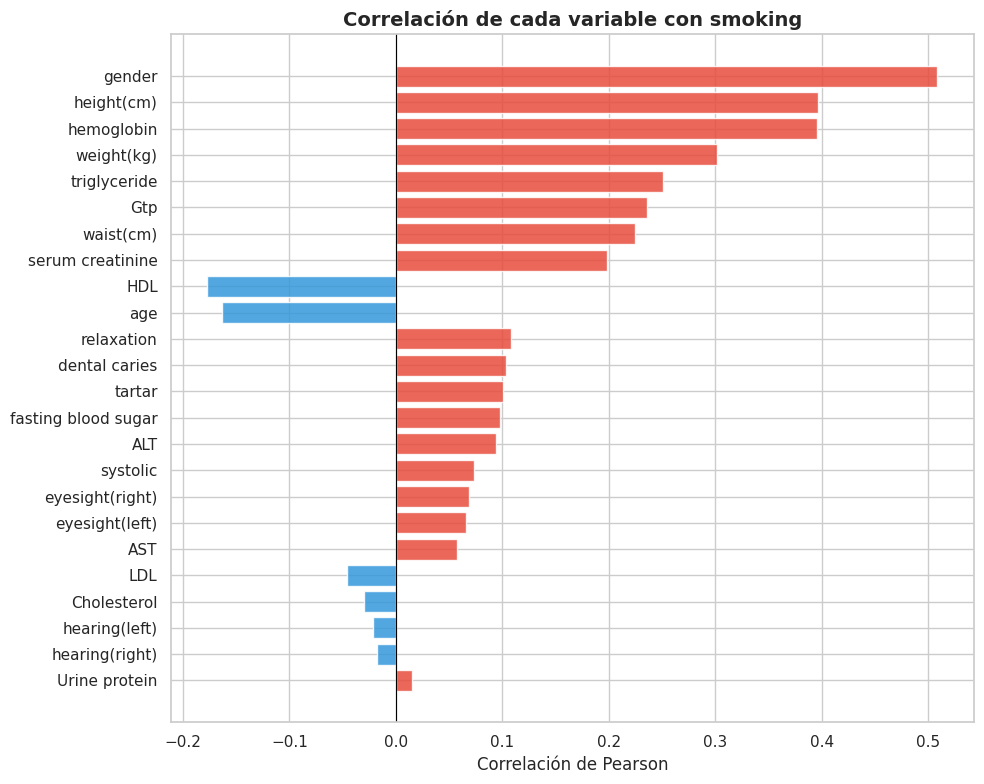

In [4]:
# Visualización de la correlación con el target
fig, ax = plt.subplots(figsize=(10, 8))

colores = ['#E74C3C' if c > 0 else '#3498DB' for c in corr_target.values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1],
        color=colores[::-1], edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de cada variable con smoking',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

**🌟 Variable estrella encontrada:** `gender` tiene la correlación más alta con el target (≈ 0.51), muy por encima del resto. Esto significa que el sexo biológico es el predictor más fuerte de si una persona fuma o no en este dataset.

Le siguen `height(cm)` y `hemoglobin` (≈ 0.40 cada una). Es importante notar que estas dos también están correlacionadas con el sexo — los hombres tienden a ser más altos y a tener más hemoglobina — por lo que parte de su poder predictivo proviene indirectamente del sexo.

Confirmaremos esto en el notebook de entrenamiento con la **importancia de features** del modelo, que es una medida más robusta que la correlación lineal.

In [5]:
# Verificamos la relación gender vs smoking directamente
tabla = pd.crosstab(df['gender'], df['smoking'], normalize='index') * 100
tabla.columns = ['No fuma (%)', 'Fuma (%)']
print('Tasa de tabaquismo por sexo:')
print(tabla.round(1))
print()
print('→ La diferencia es enorme: confirma por qué gender es tan predictivo.')

Tasa de tabaquismo por sexo:
        No fuma (%)  Fuma (%)
gender                       
F              95.7       4.3
M              44.8      55.2

→ La diferencia es enorme: confirma por qué gender es tan predictivo.


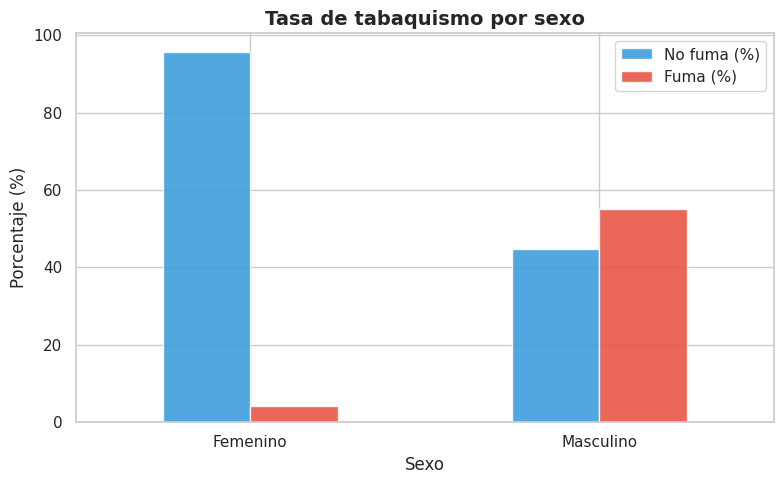

In [6]:
# Gráfico de la tasa de tabaquismo por sexo
fig, ax = plt.subplots(figsize=(8, 5))
tabla.plot(kind='bar', ax=ax, color=['#3498DB', '#E74C3C'], alpha=0.85, edgecolor='white')
ax.set_title('Tasa de tabaquismo por sexo', fontsize=14, fontweight='bold')
ax.set_xlabel('Sexo')
ax.set_ylabel('Porcentaje (%)')
ax.set_xticklabels(['Femenino', 'Masculino'], rotation=0)
ax.legend(title='')
plt.tight_layout()
plt.show()

## 3. Matriz de correlación entre features

Buscamos variables redundantes — pares de features muy correlacionadas entre sí. Cuando dos variables aportan casi la misma información, mantener ambas no mejora el modelo y puede introducir multicolinealidad.

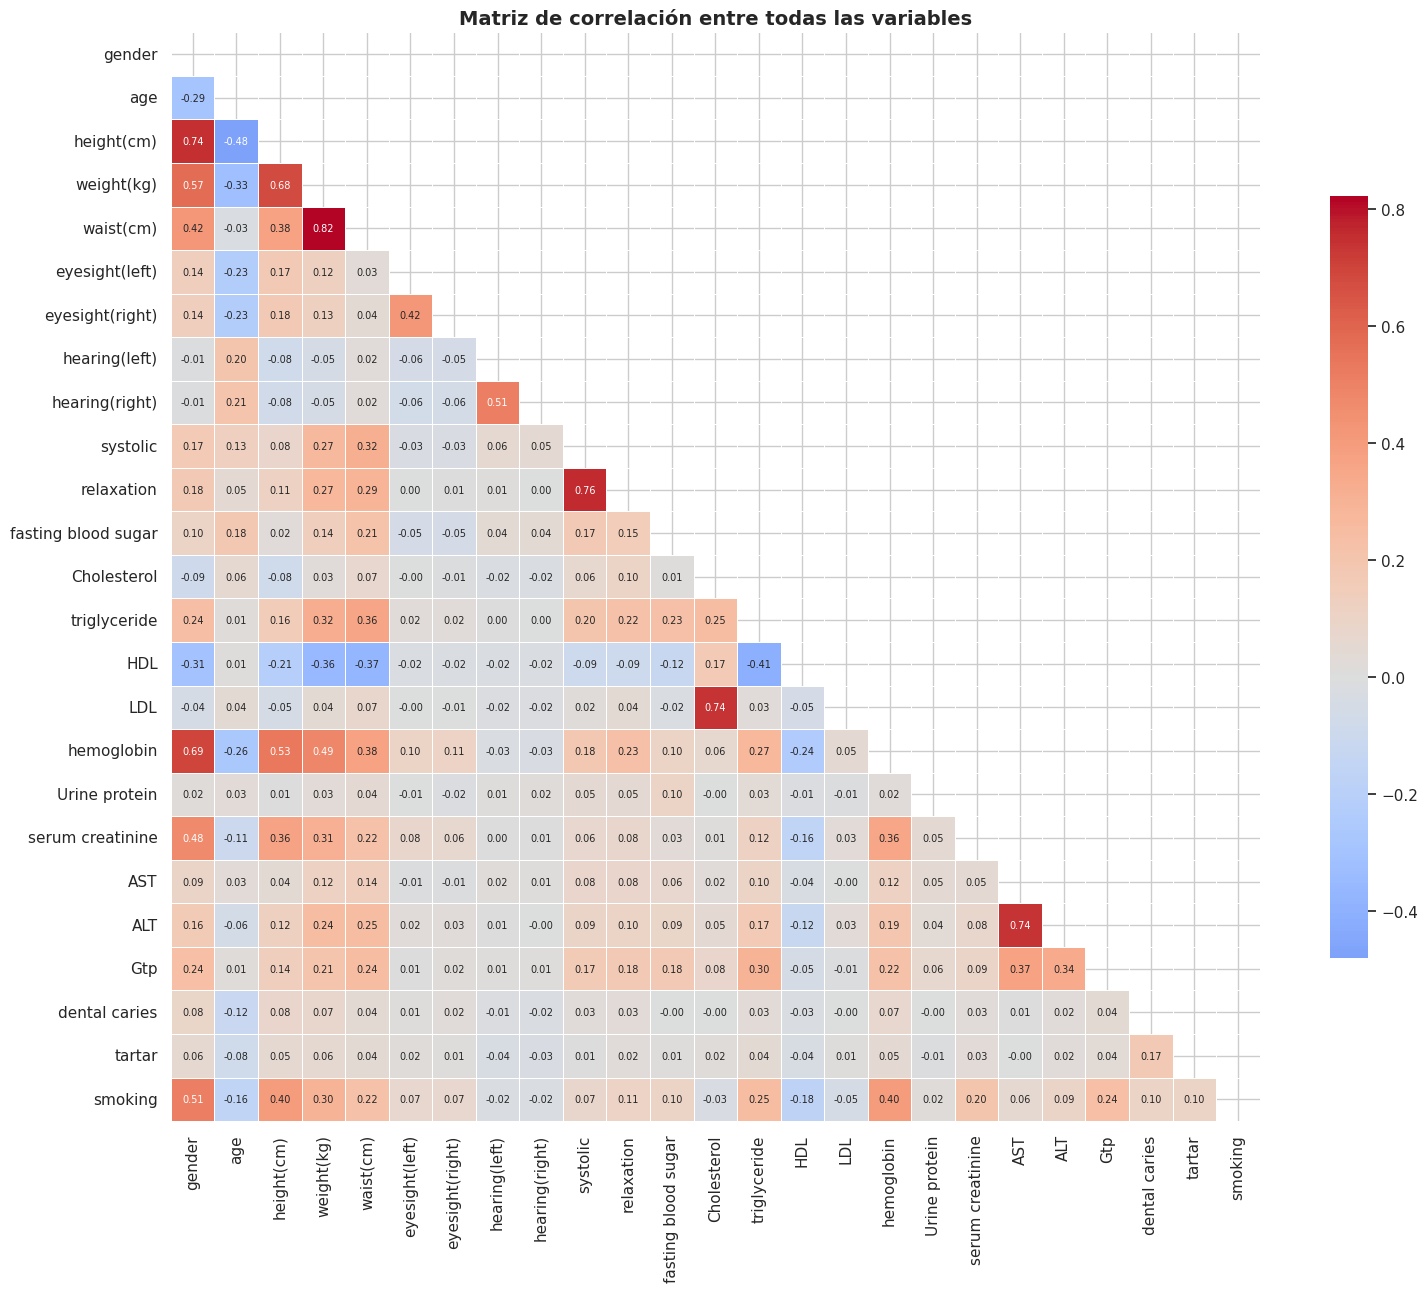

In [7]:
fig, ax = plt.subplots(figsize=(16, 13))
matriz = df_corr.corr()
mask = np.triu(np.ones_like(matriz, dtype=bool))
sns.heatmap(matriz, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.7}, annot_kws={'size': 7})
ax.set_title('Matriz de correlación entre todas las variables',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Identificamos pares de features con correlación alta (posible redundancia)
matriz_features = df_corr.drop(columns=['smoking']).corr().abs()
pares = []
for i in range(len(matriz_features.columns)):
    for j in range(i+1, len(matriz_features.columns)):
        c = matriz_features.iloc[i, j]
        if c > 0.6:
            pares.append((matriz_features.columns[i], matriz_features.columns[j], c))

print('Pares de features con correlación > 0.6 (posible redundancia):')
print()
if pares:
    for a, b, c in sorted(pares, key=lambda x: -x[2]):
        print(f'  {a:<20} ↔ {b:<20}: {c:.3f}')
else:
    print('  No hay pares con correlación mayor a 0.6')

Pares de features con correlación > 0.6 (posible redundancia):

  weight(kg)           ↔ waist(cm)           : 0.823
  systolic             ↔ relaxation          : 0.761
  gender               ↔ height(cm)          : 0.742
  Cholesterol          ↔ LDL                 : 0.740
  AST                  ↔ ALT                 : 0.739
  gender               ↔ hemoglobin          : 0.693
  height(cm)           ↔ weight(kg)          : 0.676


## 4. Distribuciones de las variables más predictivas

Visualizamos cómo se distribuyen las variables top según fumadores vs no fumadores. Si las distribuciones están bien separadas, la variable es útil para discriminar.

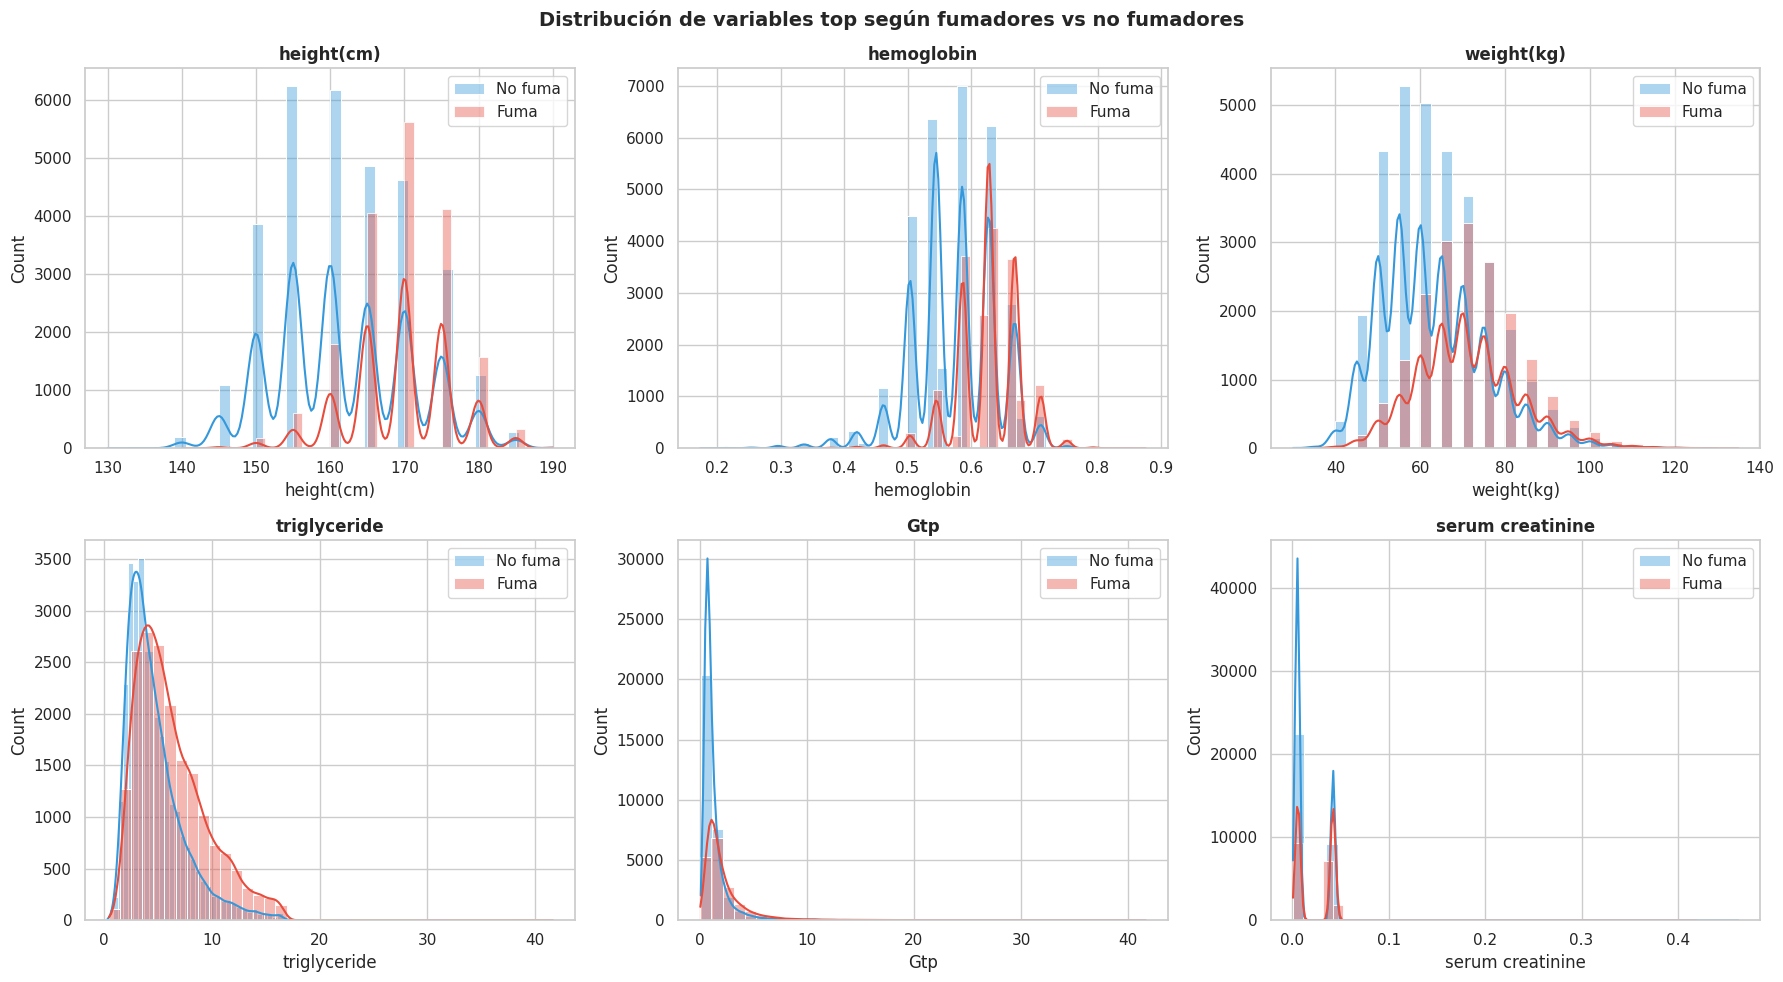

In [9]:
top_vars = ['height(cm)', 'hemoglobin', 'weight(kg)', 'triglyceride', 'Gtp', 'serum creatinine']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    for clase, color, label in [(0, '#3498DB', 'No fuma'), (1, '#E74C3C', 'Fuma')]:
        datos = df[df['smoking'] == clase][var]
        sns.histplot(datos, kde=True, label=label, color=color,
                     alpha=0.4, bins=40, ax=axes[i])
    axes[i].set_title(f'{var}', fontsize=12, fontweight='bold')
    axes[i].legend()

plt.suptitle('Distribución de variables top según fumadores vs no fumadores',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Boxplots: detección de outliers en variables clave

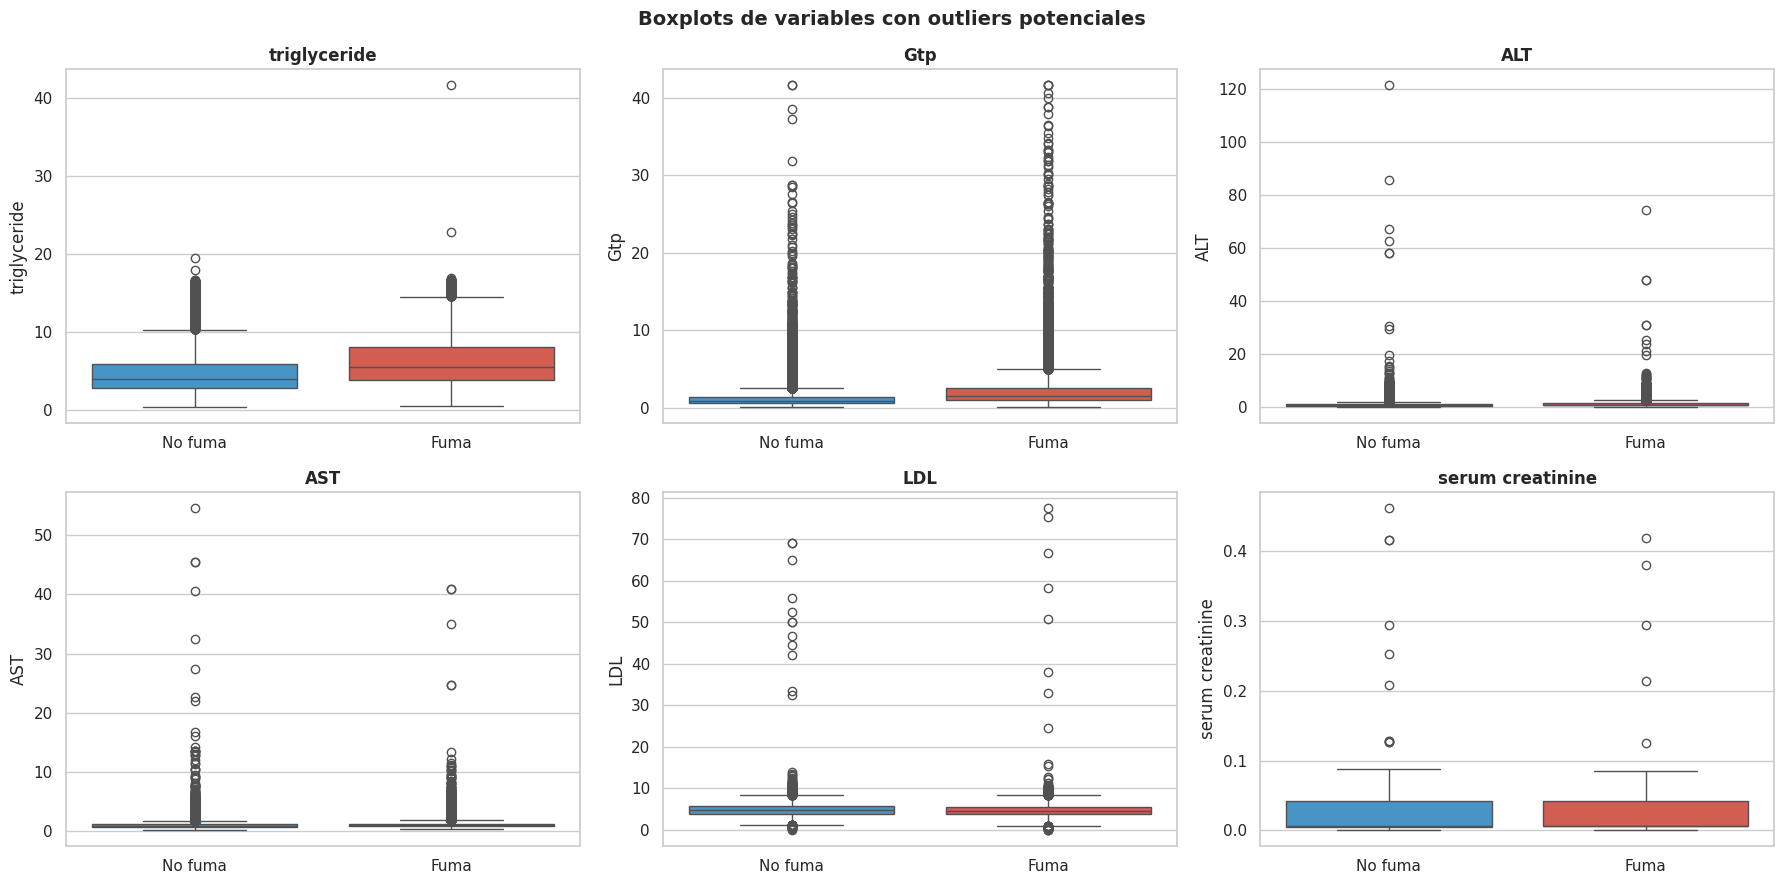

In [10]:
vars_box = ['triglyceride', 'Gtp', 'ALT', 'AST', 'LDL', 'serum creatinine']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, var in enumerate(vars_box):
    sns.boxplot(data=df, x='smoking', y=var, ax=axes[i], palette=['#3498DB', '#E74C3C'])
    axes[i].set_title(f'{var}', fontsize=12, fontweight='bold')
    axes[i].set_xticklabels(['No fuma', 'Fuma'])
    axes[i].set_xlabel('')

plt.suptitle('Boxplots de variables con outliers potenciales',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Varias variables (enzimas hepáticas como `Gtp`, `ALT`, `AST`, y `triglyceride`) tienen outliers marcados. Los modelos basados en árboles (RandomForest, XGBoost) que usaremos son **robustos a outliers** porque dividen el espacio en regiones y no se ven afectados por valores extremos como sí lo estarían modelos lineales. Por eso no los eliminaremos — solo los documentamos.

## Conclusiones del EDA

**Variables a eliminar:**
- `ID` — identificador, no aporta señal.
- `oral` — un solo valor, sin varianza.

**Variable estrella:**
- `gender` es el predictor más fuerte (correlación ≈ 0.51 con el target). La tasa de tabaquismo masculina es muchísimo mayor que la femenina en este dataset.

**Variables muy predictivas:**
- `height(cm)`, `hemoglobin`, `weight(kg)`, `triglyceride`, `Gtp` — todas con correlación relevante, varias asociadas indirectamente al sexo.

**Decisiones para el preprocesamiento:**
- Mantener todas las features salvo `ID` y `oral`.
- Encodear `gender` y `tartar` (categóricas).
- No eliminar outliers porque usaremos modelos de árboles robustos a ellos.
- Para KNN (sensible a escala) aplicaremos un scaler; para árboles no es necesario.

La decisión de mantener variables correlacionadas entre sí (como height y gender) la dejamos para que el modelo la resuelva — los árboles manejan bien la redundancia mediante la selección de features en cada split.